# TP3 - Détection et Traitement des Outliers

**Difficulté:** Intermédiaire  
**Dataset:** sales_outliers.csv  
**Description:** Identification des valeurs aberrantes avec méthodes statistiques

---


## Imports des Bibliothèques


In [437]:
# Bibliothèques de base
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from scipy import stats


# Configuration des graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Ignorer les warnings
import warnings
warnings.filterwarnings('ignore')

# Affichage pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

print(" Bibliothèques importées avec succès!")

 Bibliothèques importées avec succès!


## Import du Dataset


In [438]:
# Charger le dataset
df = pd.read_csv('../data/sales_outliers.csv')

# Afficher les informations de base
print(f"📏 Dimensions: {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f" Taille mémoire: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("\n" + "="*80 + "\n")

# Aperçu des données
display(df.head())
print("\n" + "="*80 + "\n")

# Informations sur les colonnes
df.info()

📏 Dimensions: 1020 lignes × 4 colonnes
 Taille mémoire: 0.12 MB




,transaction_id,amount,product,date
0,1,1458.56,B,2023-01-01
1,2,4399.43,B,2023-01-02
2,3,1298.67,C,2023-01-03
3,4,1580.76,A,2023-01-04
4,5,946.03,C,2023-01-05




<class 'pandas.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   transaction_id  1020 non-null   int64  
 1   amount          1020 non-null   float64
 2   product         1020 non-null   str    
 3   date            1020 non-null   str    
dtypes: float64(1), int64(1), str(2)
memory usage: 32.0 KB


## Visualisation des Valeurs Manquantes


<Figure size 1400x800 with 0 Axes>

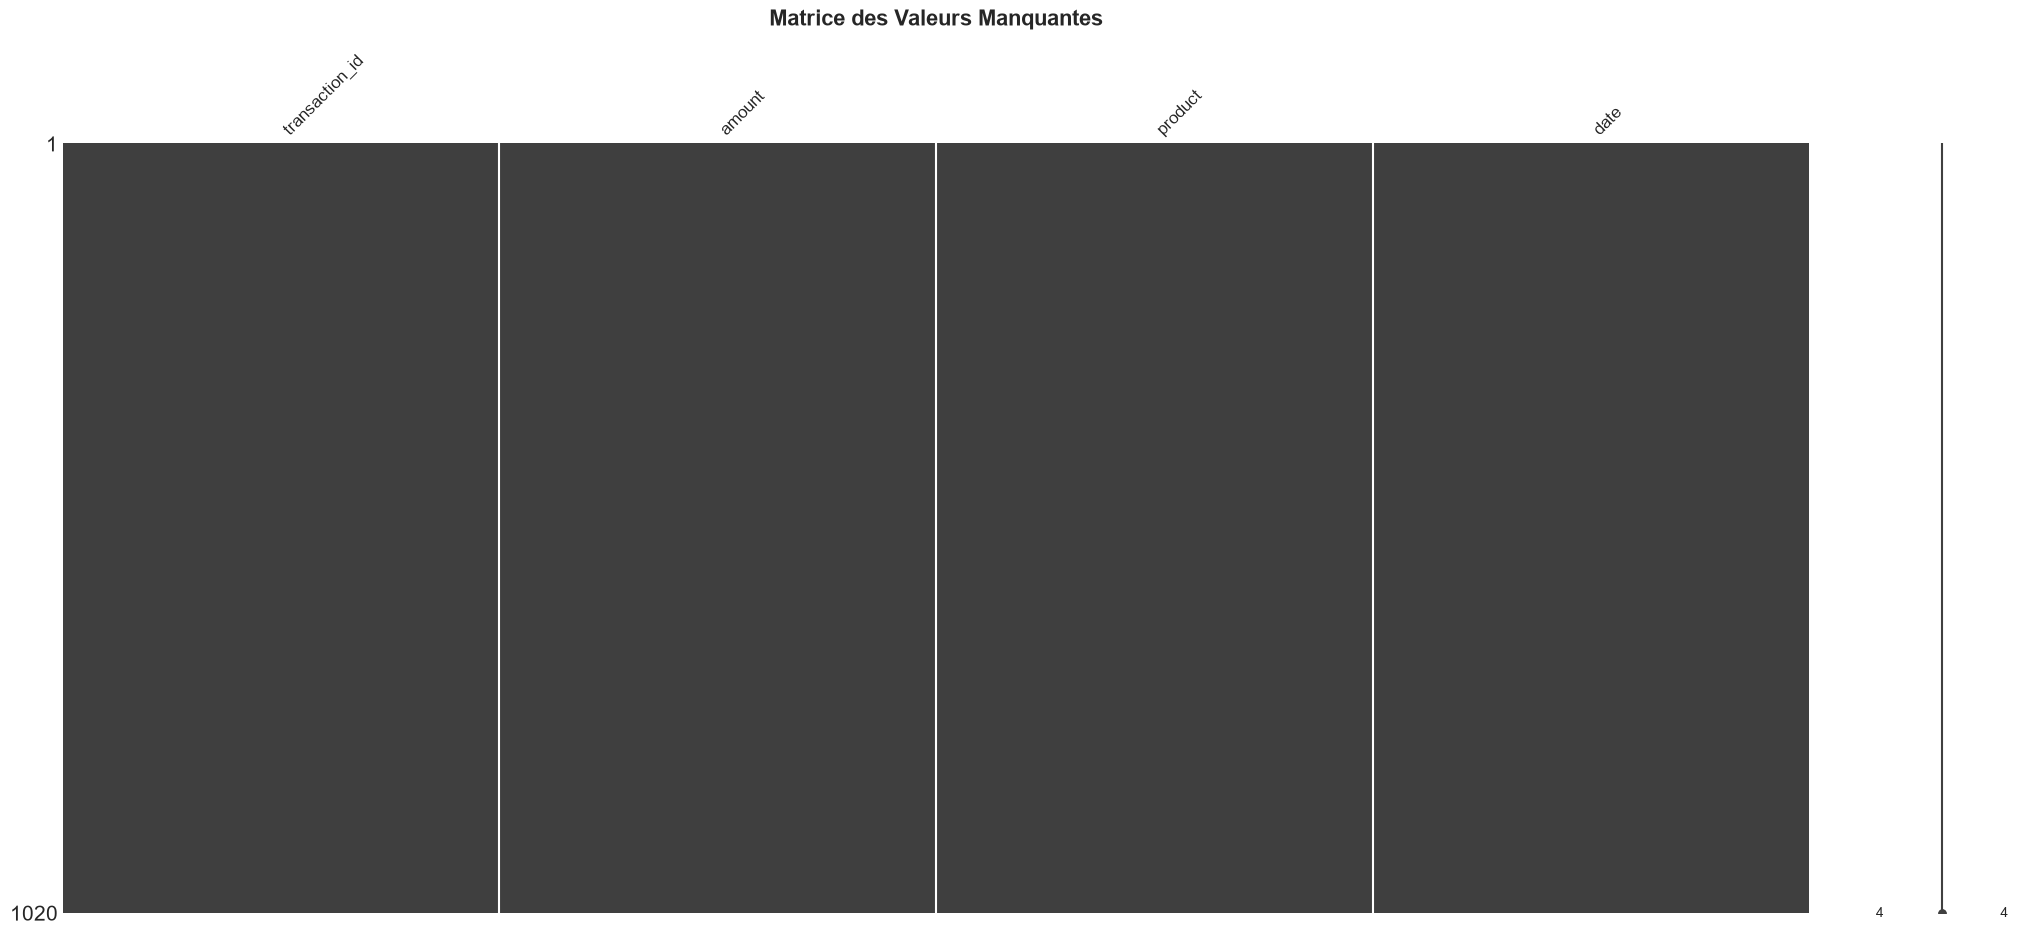


📊 Statistiques des Valeurs Manquantes:



,Nombre_Missing,Pourcentage_Missing


In [439]:
# Matrice de visualisation des valeurs manquantes
plt.figure(figsize=(14, 8))
msno.matrix(df, fontsize=12, sparkline=True)
plt.title("Matrice des Valeurs Manquantes", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Statistiques des valeurs manquantes
missing_stats = pd.DataFrame({
    'Nombre_Missing': df.isnull().sum(),
    'Pourcentage_Missing': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Pourcentage_Missing', ascending=False)

print("\n📊 Statistiques des Valeurs Manquantes:\n")
display(missing_stats[missing_stats['Nombre_Missing'] > 0])


## Questions Préalables

**Avant de commencer le TP, répondez aux questions suivantes en analysant le dataset:**

1. Quelle est la distribution de la colonne 'amount' ?
2. Y a-t-il des valeurs négatives dans les montants ?
3. Quel est le montant maximum et semble-t-il aberrant ?
4. Combien d'outliers détecte la méthode IQR pour 'amount' ?
5. Combien d'outliers détecte la méthode Z-score (threshold=3) ?
6. Les deux méthodes identifient-elles les mêmes outliers ?
7. Quelle proportion du dataset représentent les outliers ?
8. Y a-t-il une corrélation entre outliers et une catégorie spécifique ?
9. Les outliers sont-ils des erreurs ou des valeurs légitimes ?
10. Comment la moyenne change-t-elle après traitement des outliers ?


In [440]:
# Cellule pour vos réponses et analyses
# Utilisez cette cellule pour explorer les données et répondre aux questions

# Exemple d'analyses:
# df.describe()
# df['colonne'].value_counts()
# df.isnull().sum()
# etc.


# Écrivez vos réponses ici
print("Réponses aux questions:")
print("="*80)

#1.
df_distribution = df["amount"].describe()
print(df_distribution)
#2
df_negatif =(df["amount"] < 0).any()
print(f"\nresultat de valeur négatives touver : {df_negatif}")
#3
print(f"valeur maximal = {df["amount"].max()}")

#4 Outlier avec méthode IQR
q1= df["amount"].quantile(0.25)
q3 = df["amount"].quantile(0.75)
iqr = q3 - q1
upper_bound  = q3 + 1.5*iqr
lower_bound  =  q1 - 1.5*iqr
#outliers 
outliers_iqr = df[((df["amount"]< lower_bound ) | (df["amount"]> upper_bound))]
print(f"\nil y'a : {len(outliers_iqr["amount"])} outliers pour 'amount'")

#5 Outliers avec méthode Z-score
# Calcul du Z-score
z_scores = np.abs(stats.zscore(df["amount"]))
threshold = 3
#detection des outliers
outliers_zscore = df[z_scores > threshold]
print(f"Outliers détéctés: {len(outliers_zscore)}")

#6
if set(outliers_iqr) == set(outliers_zscore) :
    print("il identifient les même outliers")
else:
    print("il identifient pas les même outliers")

#7. Quelle proportion du dataset représentent les outliers
proportion_iqr = (len(outliers_iqr) / len(df))
print(f"proportion outliers iqr  : {proportion_iqr:.2%}")
proportion_z_score = len(outliers_zscore) / len(df)
print(f"proportion outliers z_score  : {proportion_z_score:.2%}")

#8.
display(outliers_iqr["product"].value_counts(normalize=True) *100)
df["product"].value_counts(normalize=True) * 100
print(f"8. le produit C et légérement surreprésenté parmi les outliers 37,14% contre 34,71% dans le dataset ")

#9.  Les outliers sont-ils des erreurs ou des valeurs légitimes
print("""les outliers semble etre des valeurs réel que des erreurs  
      il aucune valeurs négative a etait détéctée et 
      les outliers sont bien repartis entre les differents product
      """)

#10. Comment la moyenne change-t-elle après traitement des outliers ?
print(f"La moyenne du dataset de base {df["amount"].mean()}")
df_clean_outlier_iqr = df.drop(outliers_iqr.index)
df_clean_outlier_zscore = df.drop(outliers_zscore.index)

print(f"La moyenne avec sans les outliers iqr = {df_clean_outlier_iqr["amount"].mean()}")
print(f"La moyenne avec sans les outliers z_score {df_clean_outlier_zscore["amount"].mean()}")
print("on remarque une baise synificatife de la moyenne apres avoir enlever les outliers")

Réponses aux questions:
count     1020.00
mean      8616.96
std      20525.04
min         79.57
25%       1441.20
50%       3152.76
75%       7221.39
max     185913.06
Name: amount, dtype: float64

resultat de valeur négatives touver : False
valeur maximal = 185913.06

il y'a : 105 outliers pour 'amount'
Outliers détéctés: 22
il identifient les même outliers
proportion outliers iqr  : 10.29%
proportion outliers z_score  : 2.16%


product
C   37.14
A   32.38
B   30.48
Name: proportion, dtype: float64

8. le produit C et légérement surreprésenté parmi les outliers 37,14% contre 34,71% dans le dataset 
les outliers semble etre des valeurs réel que des erreurs  
      il aucune valeurs négative a etait détéctée et 
      les outliers sont bien repartis entre les differents product
      
La moyenne du dataset de base 8616.955029411763
La moyenne avec sans les outliers iqr = 3952.3558142076504
La moyenne avec sans les outliers z_score 5944.724348697395
on remarque une baise synificatife de la moyenne apres avoir enlever les outliers


## Étapes du TP

**Suivez les étapes ci-dessous pour nettoyer le dataset:**

### Étape 1: Visualiser la distribution avec boxplot et histogramme
### Étape 2: Calculer les statistiques descriptives
### Étape 3: Implémenter la détection par méthode IQR
### Étape 4: Implémenter la détection par Z-score
### Étape 5: Comparer les résultats des deux méthodes
### Étape 6: Décider d'une stratégie: suppression ou capping
### Étape 7: Appliquer le capping (Winsorization) aux valeurs extrêmes
### Étape 8: Visualiser la distribution avant/après traitement
### Étape 9: Calculer l'impact sur les statistiques (moyenne, écart-type)
### Étape 10: Documenter les outliers traités dans un rapport


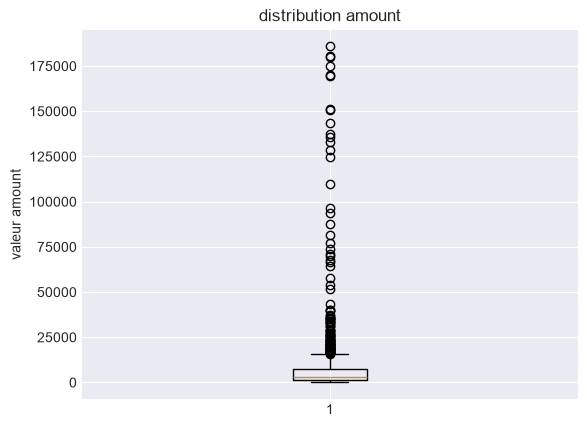

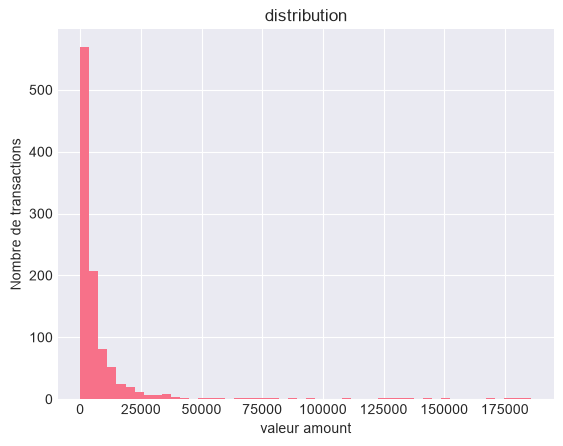

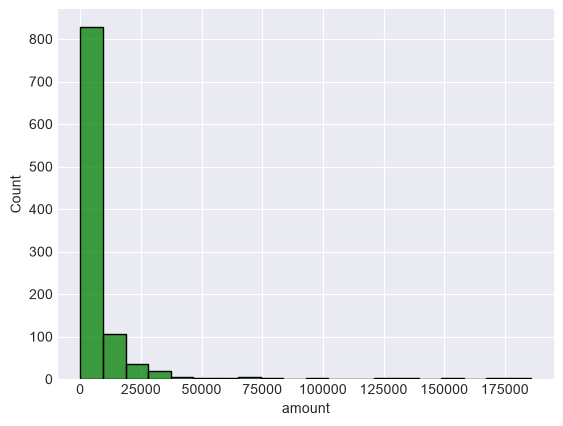

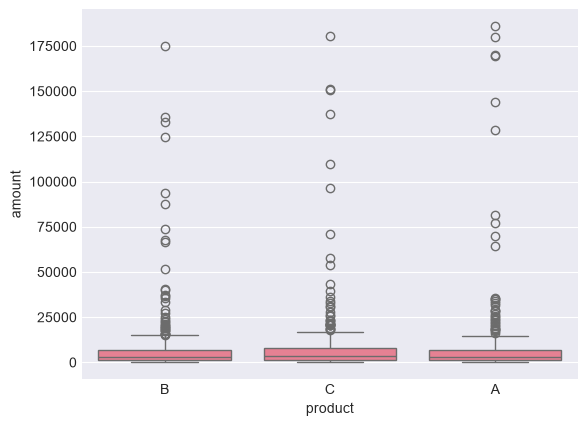

 Étape 1 complétée


In [454]:
# ========================================
# Étape 1: Visualiser la distribution avec boxplot et histogramme
# ========================================

# TODO: Écrivez votre code ici
#distribution Global
plt.boxplot(df["amount"])
plt.title("distribution amount")
plt.ylabel("valeur amount")
plt.show()

plt.hist(df["amount"],bins=50)
plt.title("distribution")
plt.xlabel("valeur amount")
plt.ylabel("Nombre de transactions")
plt.show()

############################ SNS ########################
# Distribution par 'product'
sns.histplot(data=df,x="amount", color='green',edgecolor="black",bins=20)
plt.show()

sns.boxplot(data=df, x="product",y="amount")

plt.show()
# Vérification
print(f" Étape 1 complétée")

In [442]:
# ========================================
# Étape 2: Calculer les statistiques descriptives
# ========================================

# TODO: Écrivez votre code ici
display(df.describe())
# Vérification
print(f" Étape 2 complétée")

,transaction_id,amount
count,1020.00,1020.00
mean,510.50,8616.96
std,294.59,20525.04
min,1.00,79.57
25%,255.75,1441.20
50%,510.50,3152.76
75%,765.25,7221.39
max,1020.00,185913.06


 Étape 2 complétée


In [443]:
# ========================================
# Étape 3: Implémenter la détection par méthode IQR
# ========================================

# TODO: Écrivez votre code ici

q1= df["amount"].quantile(0.25)
q3 = df["amount"].quantile(0.75)
iqr = q3 - q1
upper_bound  = q3 + 1.5*iqr
lower_bound  =  q1 - 1.5*iqr
#outliers 
outliers_iqr = df[((df["amount"]< lower_bound ) | (df["amount"]> upper_bound))]
print(f"\nil y'a : {len(outliers_iqr["amount"])} outliers pour 'amount'")


# Vérification
print(f" Étape 3 complétée")


il y'a : 105 outliers pour 'amount'
 Étape 3 complétée


In [444]:
# ========================================
# Étape 4: Implémenter la détection par Z-score
# ========================================

# TODO: Écrivez votre code ici
outliers_zscore = df[z_scores > threshold]
print(f"z_score : {len(outliers_zscore)}")


# Vérification
print(f" Étape 4 complétée")

z_score : 22
 Étape 4 complétée


In [445]:
# ========================================
# Étape 5: Comparer les résultats des deux méthodes
# ========================================

# TODO: Écrivez votre code ici
print("la methode iqr trouve plus outliers que la methode z_score qui a plus grande tolérance pour les valeurs abérante")

# Vérification
print(f" Étape 5 complétée")

la methode iqr trouve plus outliers que la methode z_score qui a plus grande tolérance pour les valeurs abérante
 Étape 5 complétée


In [446]:
# ========================================
# Étape 6: Décider d'une stratégie: suppression ou capping
# ========================================

# TODO: Écrivez votre code ici
print("je choisit le Capping (Winsorization)")


# Vérification
print(f" Étape 6 complétée")

je choisit le Capping (Winsorization)
 Étape 6 complétée


 Étape 7 complétée


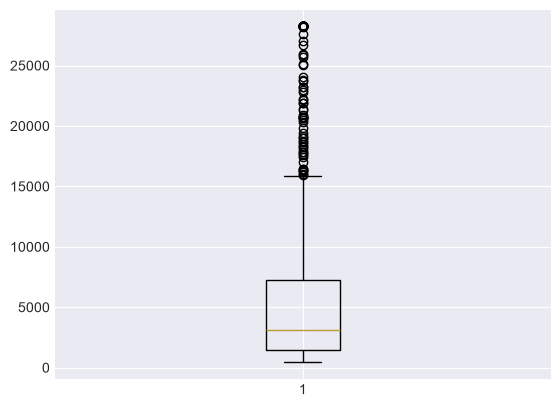

In [447]:
# ========================================
# Étape 7: Appliquer le capping (Winsorization) aux valeurs extrêmes
# ========================================

# TODO: Écrivez votre code ici

p5= df["amount"].quantile(0.05)
p95 = df["amount"].quantile(0.95)
df_clean = df.copy()
df_clean['amount'] = df_clean['amount'].clip(lower=p5, upper=p95)
plt.boxplot(df_clean["amount"])

# Vérification
print(f" Étape 7 complétée")

 Étape 8 complétée


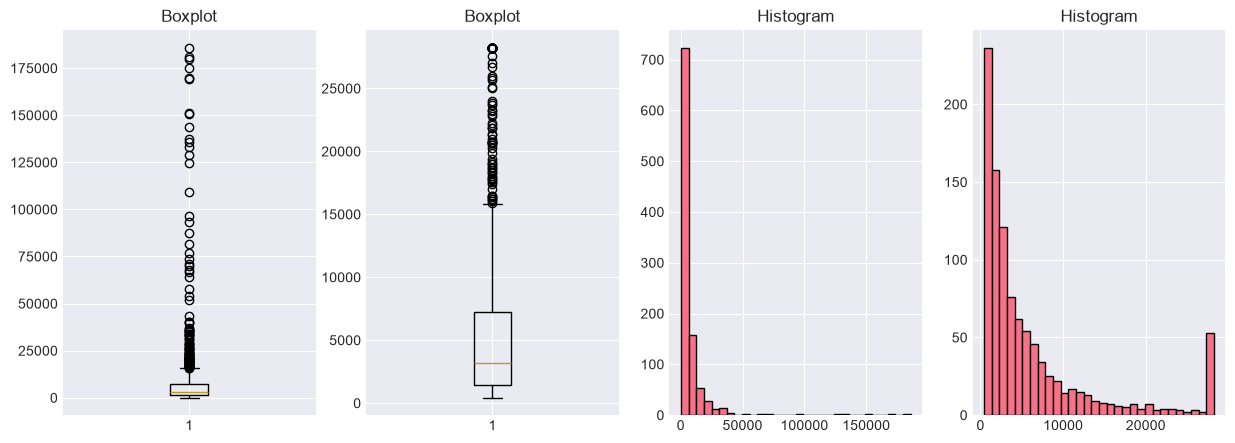

In [448]:
# ========================================
# Étape 8: Visualiser la distribution avant/après traitement
# ========================================

# TODO: Écrivez votre code ici
fig, axes = plt.subplots(1, 4, figsize=(15, 5))
# Boxplot
axes[0].boxplot(df['amount'])
axes[0].set_title('Boxplot')
axes[1].boxplot(df_clean['amount'])
axes[1].set_title('Boxplot')

#histogram
axes[2].hist(df['amount'], bins=30, edgecolor='black')
axes[2].set_title('Histogram')
axes[3].hist(df_clean['amount'], bins=30, edgecolor='black')
axes[3].set_title('Histogram')

# Vérification
print(f" Étape 8 complétée")

In [452]:
# ========================================
# Étape 9: Calculer l'impact sur les statistiques (moyenne, écart-type)
# ========================================

# TODO: Écrivez votre code ici
display(df.describe())
display(df_clean.describe())
print("impact sur la moyenne et écrart-type et quel sont diminuer au dataset initial")
# Vérification
print(f" Étape 9 complétée")

,transaction_id,amount
count,1020.00,1020.00
mean,510.50,8616.96
std,294.59,20525.04
min,1.00,79.57
25%,255.75,1441.20
50%,510.50,3152.76
75%,765.25,7221.39
max,1020.00,185913.06


,transaction_id,amount
count,1020.00,1020.00
mean,510.50,6066.40
std,294.59,7187.67
min,1.00,439.73
25%,255.75,1441.20
50%,510.50,3152.76
75%,765.25,7221.39
max,1020.00,28244.08


impact sur la moyenne et écrart-type et quel sont diminuer au dataset initial
 Étape 9 complétée


In [ ]:
# ========================================
# Étape 10: Documenter les outliers traités dans un rapport
# ========================================

# TODO: Écrivez votre code ici
print(f"méthode iqr : {len(outliers_iqr)}")
print(f"méthode z_score : {len(outliers_zscore)}")
print(f"le capping inferieur et de {p5.round(2)}")
print(f"le capping supperieur et de {p95.round(2)}")

# Vérification
print(f" Étape 10 complétée")

méthode iqr : 105
méthode z_score : 22
le capping inferieur et de 439.73
le capping supperieur et de 28244.08
 Étape 10 complétée


## Rapport Final

**Créez un rapport résumant toutes les transformations effectuées**


In [460]:
# Rapport de nettoyage
rapport = {
    'Dimensions_initiales': df.shape,
    'Dimensions_finales': df_clean.shape,  # À mettre à jour avec df_clean
    'Lignes_supprimées': 0,
    'Colonnes_supprimées': 0,
    'Valeurs_manquantes_traitées': 0,
    'Doublons_supprimés': 0,

    'Outliers_traités': len(outliers_iqr),
    'Transformations_appliquées': [
        "capping Winsorization "
    ]
}

print("=" * 80)
print(" " * 25 + " RAPPORT DE NETTOYAGE")
print("=" * 80)

for key, value in rapport.items():
    print(f"{key:.<40} {value}")

print("=" * 80)
print("\n✅ TP terminé avec succès!")

                          RAPPORT DE NETTOYAGE
Dimensions_initiales.................... (1020, 4)
Dimensions_finales...................... (1020, 4)
Lignes_supprimées....................... 0
Colonnes_supprimées..................... 0
Valeurs_manquantes_traitées............. 0
Doublons_supprimés...................... 0
Outliers_traités........................ 105
Transformations_appliquées.............. ['capping Winsorization ']

✅ TP terminé avec succès!
